<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc">
    <ul class="toc-item">
        <li>
            <span><a href="#1.-로지스틱-회귀" data-toc-modified-id="1.-로지스틱-회귀-1">
                <span class="toc-item-num">1&nbsp;&nbsp;</span>1. 로지스틱 회귀
            </a></span>
        </li>
    </ul>
</div>
<hr>

## 1. 로지스틱 회귀

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
body = pd.read_csv(
    "https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/bodyPerformance.csv"
)

In [2]:
import numpy as np

# gender: 남자=0, 여자=1
body['gender'] = np.where(body['gender'] == 'M', 0, 1)

# 이진 분류용 레이블: A등급=1, 그 외=0
body['class_1'] = np.where(body['class'] == 'A', 1, 0)
body

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,class_1
0,27.0,0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C,0
1,25.0,0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A,1
2,31.0,0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C,0
3,32.0,0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B,0
4,28.0,0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,C,0
13389,21.0,0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,D,0
13390,39.0,0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,A,1
13391,64.0,1,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,D,0


In [3]:
from sklearn.model_selection import train_test_split

feature_columns = list(body.columns.difference(['class', 'class_1']))
X = body[feature_columns]
y = body['class_1']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.7, random_state=1
)
print(X_train.shape, X_test.shape)

(9375, 11) (4018, 11)


In [4]:
from sklearn.linear_model import LogisticRegression

logR = LogisticRegression(random_state=45)
logR.fit(X_train, y_train)

LogisticRegression(random_state=45)

In [5]:
from sklearn.metrics \
import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

pred = logR.predict(X_test)

acc = accuracy_score(y_test, pred)
prc = precision_score(y_test, pred)
rcll = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(confusion_matrix(y_test, pred))
print('\n')
print('정확도\t{}%'.format(round(acc*100, 2)))
print('정밀도\t{}%'.format(round(prc*100, 2)))
print('재현율\t{}%'.format(round(rcll*100, 2)))
print('F1\t{}%'.format(round(f1*100, 2)))

[[2768  246]
 [ 349  655]]


정확도	85.19%
정밀도	72.7%
재현율	65.24%
F1	68.77%


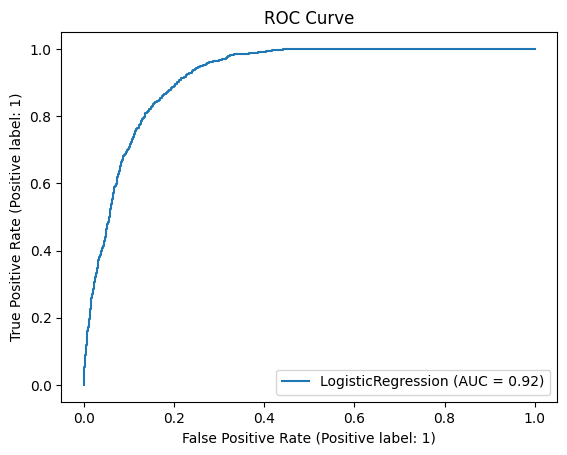

In [6]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(logR, X_test, y_test)
plt.title('ROC Curve')
plt.show()

In [7]:
# A=0, B=1, C=2, D=3 으로 매핑
mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
body['class_2'] = body['class'].map(mapping)
body

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,class_1,class_2
0,27.0,0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C,0,2
1,25.0,0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A,1,0
2,31.0,0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C,0,2
3,32.0,0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B,0,1
4,28.0,0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,C,0,2
13389,21.0,0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,D,0,3
13390,39.0,0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,A,1,0
13391,64.0,1,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,D,0,3


In [8]:
from sklearn.model_selection import train_test_split
feature_columns = list(body.columns.difference(['class','class_1','class_2']))
X = body[feature_columns]
y = body['class_2']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.7, random_state=1
)
print(X_train.shape, X_test.shape)

(9375, 11) (4018, 11)


In [9]:
from sklearn.linear_model import LogisticRegression

# 소프트맥스 회귀 활성화
softm = LogisticRegression(
    multi_class='multinomial',
    random_state=45,
)
softm.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial', random_state=45)

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score

pred = softm.predict(X_test)
acc = accuracy_score(y_test, pred)

print(confusion_matrix(y_test, pred))
print('\n')
print('정확도\t{}%'.format(round(acc*100, 2)))

[[707 259  38   0]
 [267 398 310  29]
 [ 91 203 534 177]
 [ 13  63 163 766]]


정확도	59.86%


In [11]:
# 마지막 행 데이터 예측 클래스
pred_sample = softm.predict([X_test.iloc[-1, :]])
# 각 클래스에 속할 확률
prb_sample = softm.predict_proba([X_test.iloc[-1, :]])

print('예측 클래스: ', pred_sample[0])
print('실제 클래스: ', y_test.iloc[-1])
print('각 클래스에 속할 확률', prb_sample[0])

예측 클래스:  0
실제 클래스:  0
각 클래스에 속할 확률 [0.63745386 0.30357494 0.05759374 0.00137746]


In [12]:
logR.coef_

array([[ 0.0782806 , -0.04084587,  0.00878188, -0.01830524,  0.91689218,
         0.0607419 , -0.06948161,  0.23559708,  0.11810134, -0.00190911,
        -0.05027947]])

In [13]:
np.exp(logR.coef_)

array([[1.08142607, 0.95997708, 1.00882056, 0.98186128, 2.50150408,
        1.06262462, 0.93287729, 1.26566424, 1.12535815, 0.99809271,
        0.95096362]])